# 01 — EDA & Data Quality

This notebook explores the **Online Retail II** transaction data used to train the
UK Retail Recommender.

The repo ships a committed structured-synthetic sample at
`tests/fixtures/sample_transactions.parquet` — already cleaned, with latent
cluster structure baked in. It is ready to run without downloading anything.

For the full dataset (≈1 M rows, real UK e-commerce transactions Dec 2009 – Dec 2011)
run `python scripts/download_data.py` which fetches from the UCI repository and
writes `data/raw/online_retail_II.xlsx`.

The cleaning pipeline lives in `src/data/clean.py`.


In [1]:
"""Copy-paste this as the first cell of every notebook in a portfolio project.

It walks up from the notebook's current working directory to find the project
root (the folder containing requirements.txt + src/), chdirs there, and adds
it to sys.path. After this cell runs, the notebook can:

  - import from src.x.y      (would otherwise fail with ModuleNotFoundError)
  - read relative paths like 'data/processed/...' or 'docs/...' regardless of
    where the notebook was launched from (notebooks/, project root, anywhere)
  - work the same whether launched from Jupyter, VS Code, jupyter nbconvert,
    or Colab (assuming the project was extracted to a known location there)
"""

# fmt: off
import os, sys
from pathlib import Path

_cwd = Path.cwd()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents)
     if (p / 'requirements.txt').exists() and (p / 'src').is_dir()),
    None,
)
assert _root, f'Could not find project root from {_cwd}. Open the notebook from inside the project tree.'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')
# fmt: on


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\uk-retail-recommender


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load the committed sample (no download needed)
df = pd.read_parquet("tests/fixtures/sample_transactions.parquet")
print(f"Rows        : {len(df):,}")
print(f"Customers   : {df['customer_id'].nunique():,}")
print(f"Items       : {df['item_id'].nunique():,}")
print(f"Date range  : {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows        : 2,340
Customers   : 120
Items       : 80
Date range  : 2010-01-02 to 2011-08-23


,customer_id,item_id,invoice,date,quantity,price,country
0,1000,SKU053,599664,2010-08-31,3,6.32,United Kingdom
1,1000,SKU015,567199,2011-06-26,3,19.11,United Kingdom
2,1000,SKU032,567199,2011-06-26,1,8.79,United Kingdom
3,1000,SKU011,567199,2011-06-26,3,12.59,United Kingdom
4,1000,SKU053,567199,2011-06-26,2,19.00,United Kingdom


## Top items by distinct purchasing customers

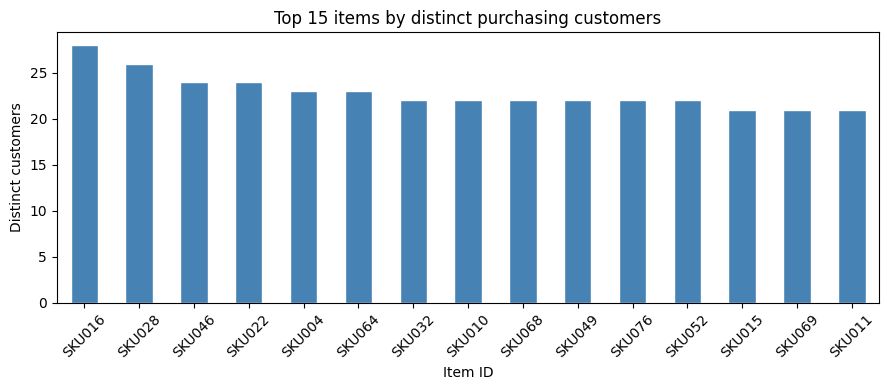

In [3]:
top_items = (
    df.groupby("item_id")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 4))
top_items.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 15 items by distinct purchasing customers")
ax.set_xlabel("Item ID")
ax.set_ylabel("Distinct customers")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Basket-size distribution (items per invoice)

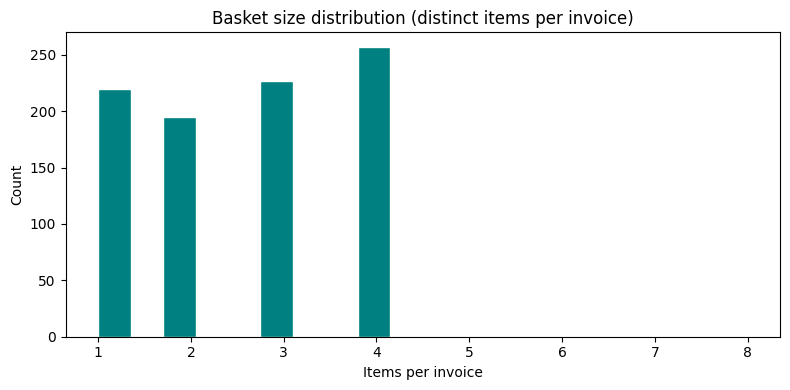

Median basket size : 3 items
Mean basket size   : 2.6 items


In [4]:
basket_sizes = df.groupby("invoice")["item_id"].nunique()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(basket_sizes, bins=20, color="teal", edgecolor="white", density=False)
ax.set_title("Basket size distribution (distinct items per invoice)")
ax.set_xlabel("Items per invoice")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f"Median basket size : {basket_sizes.median():.0f} items")
print(f"Mean basket size   : {basket_sizes.mean():.1f} items")


## Purchases per customer

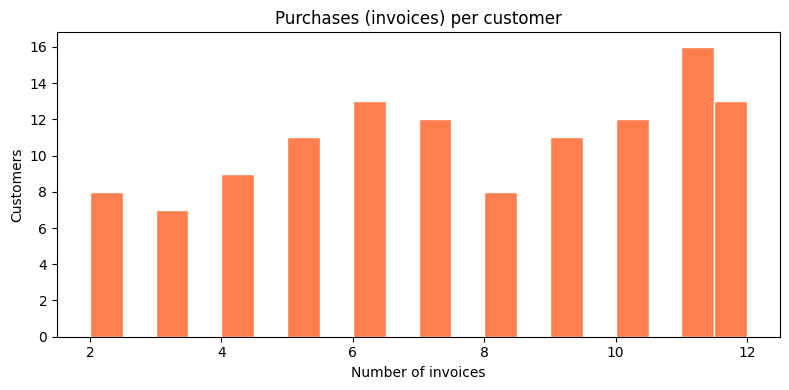

Median invoices/customer: 8
Mean invoices/customer  : 7.5


In [5]:
purchases_per_cust = df.groupby("customer_id")["invoice"].nunique()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(purchases_per_cust, bins=20, color="coral", edgecolor="white")
ax.set_title("Purchases (invoices) per customer")
ax.set_xlabel("Number of invoices")
ax.set_ylabel("Customers")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f"Median invoices/customer: {purchases_per_cust.median():.0f}")
print(f"Mean invoices/customer  : {purchases_per_cust.mean():.1f}")


## Country split

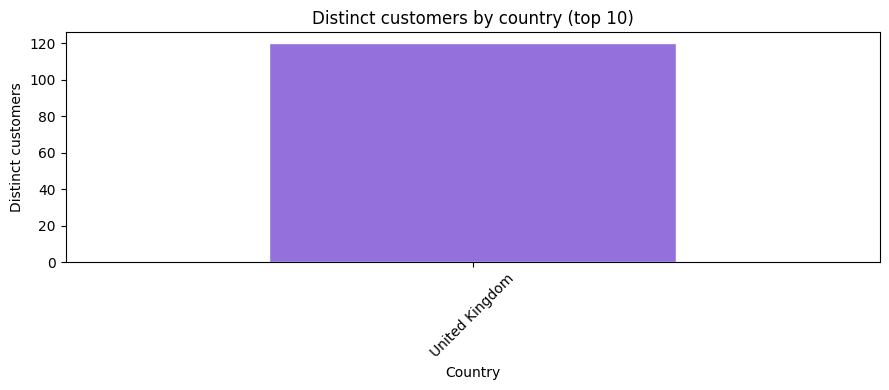

country
United Kingdom    120


In [6]:
country_counts = df.groupby("country")["customer_id"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
country_counts.head(10).plot.bar(ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title("Distinct customers by country (top 10)")
ax.set_xlabel("Country")
ax.set_ylabel("Distinct customers")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(country_counts.to_string())
